<a href="https://colab.research.google.com/github/shivamkumar359/Pneumonia_detection/blob/main/notebook/pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [2]:
import os
# List the contents of the downloaded dataset path
print(f"Contents of {path}:")

for dirname,_, filenames in os.walk(path):
  for filename in filenames:
    print(os.path.join(dirname,filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person629_bacteria_2509.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person952_bacteria_2877.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1315_virus_2270.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1392_bacteria_3538.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person475_bacteria_2025.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1288_bacteria_3251.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1005_virus_1688.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person442_virus_900.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person755_bacteria_2659.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person655_bacteria_2547.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray

In [3]:
import os

# Define the base directory for the images
base_dir = os.path.join(path, 'chest_xray', 'chest_xray')

# Define categories (train, val, test) and classes (NORMAL, PNEUMONIA)
categories = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

# Dictionary to store image counts
image_counts = {}

# Iterate through categories and classes to count images
for category in categories:
    image_counts[category] = {}
    for cls in classes:
        dir_path = os.path.join(base_dir, category, cls)
        if os.path.exists(dir_path):
            # Filter for actual image files (e.g., .jpeg, .png, etc.)
            count = len([name for name in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, name)) and not name.startswith('.')])
            image_counts[category][cls] = count
        else:
            image_counts[category][cls] = 0

# Print the counts
print("Image counts per category and class:")
for category, classes_data in image_counts.items():
    print(f"\nCategory: {category.upper()}")
    for cls, count in classes_data.items():
        print(f"  {cls}: {count} images")


Image counts per category and class:

Category: TRAIN
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

Category: VAL
  NORMAL: 8 images
  PNEUMONIA: 8 images

Category: TEST
  NORMAL: 234 images
  PNEUMONIA: 390 images


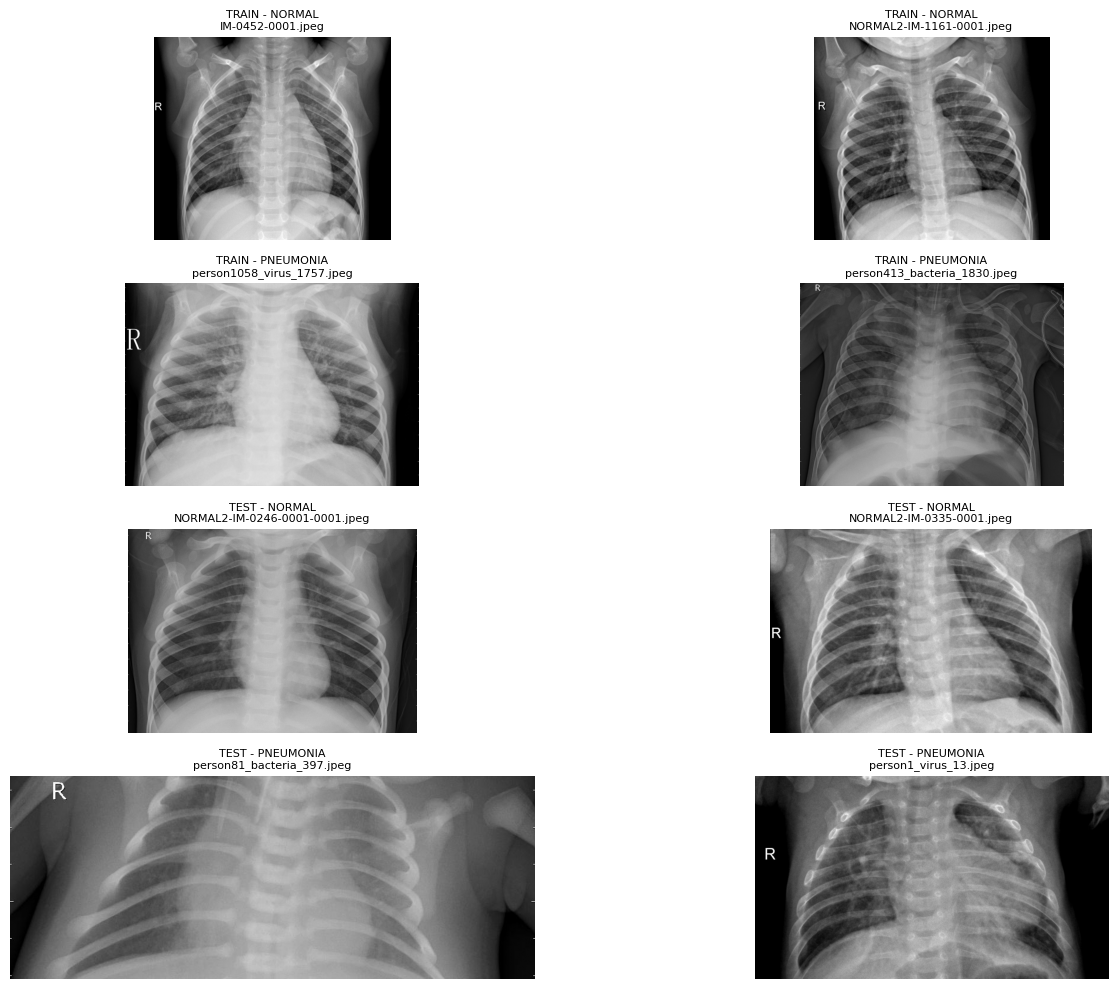

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Function to display sample images
def display_sample_images(base_dir, categories, classes, num_samples_per_class=2):
    plt.figure(figsize=(15, 10))
    plot_index = 1

    for category in categories:
        for cls in classes:
            dir_path = os.path.join(base_dir, category, cls)
            if os.path.exists(dir_path):
                # Get all image files, excluding hidden files like .DS_Store
                images = [f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f)) and not f.startswith('.')]

                if images:
                    # Randomly select a few images
                    sample_images = random.sample(images, min(len(images), num_samples_per_class))

                    for img_name in sample_images:
                        img_path = os.path.join(dir_path, img_name)
                        img = mpimg.imread(img_path)

                        plt.subplot(len(categories) * len(classes), num_samples_per_class, plot_index)
                        plt.imshow(img, cmap='gray') # X-ray images are usually grayscale
                        plt.title(f'{category.upper()} - {cls}\n{img_name}', fontsize=8)
                        plt.axis('off')
                        plot_index += 1
                else:
                    print(f"No images found in {dir_path}")
            else:
                print(f"Directory not found: {dir_path}")

    plt.tight_layout()
    plt.show()

# Display sample images from TRAIN and TEST categories for both classes
display_sample_images(base_dir, ['train', 'test'], classes, num_samples_per_class=2)


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
img_width, img_height = 150, 150  # Common dimensions for image classification
batch_size = 32

# Define paths for train and test sets
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
# The original 'val_dir' will no longer be used directly as we will create validation split from train_dir


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================
# Training Data Augmentation (with validation split)
# =========================

# For training, we apply data augmentation and set aside a validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% of training data will be used for validation
)

In [10]:
# =========================
# Test Data Rescaling
# =========================

# For test sets, only rescaling is needed
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [11]:
# =========================
# Training Generator
# =========================

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='training', # Specify this as the training subset
    shuffle=True
)

Found 4173 images belonging to 2 classes.


In [12]:
# =========================
# Validation Generator
# =========================

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation', # Specify this as the validation subset
    shuffle=False # No need to shuffle validation data
)

Found 1043 images belonging to 2 classes.


In [13]:
# =========================
# Test Generator
# =========================

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False # Do not shuffle test data to maintain order for evaluation
)

Found 624 images belonging to 2 classes.


## Improving Model Accuracy with Transfer Learning

As discussed, to further enhance the model's performance, we will leverage Transfer Learning. This technique involves using a pre-trained neural network (a model that has already been trained on a massive dataset like ImageNet) and adapting it to our specific task. The pre-trained model has learned to recognize a wide variety of features from images, and these learned features can be incredibly useful for new, related tasks like medical image classification, even with smaller datasets.

We will use MobileNetV2 as the base of our new model. We'll add our own classification layers on top of this pre-trained base, allowing the model to learn the specific nuances of pneumonia detection while benefiting from the powerful feature extraction capabilities of the pre-trained network.

In [14]:
from tensorflow.keras.applications import MobileNetV2 # You can choose other models like VGG16, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the pre-trained MobileNetV2 model, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Freeze the layers of the base model to prevent them from being updated during training
# This preserves the learned features from ImageNet
base_model.trainable = False

# Create a new model on top of the pre-trained base
x = base_model.output
x = GlobalAveragePooling2D()(x) # Add a Global Average Pooling layer
x = Dense(128, activation='relu')(x) # Add a new dense layer
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

# Combine the base model and our new layers
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the new model with an appropriate learning rate
transfer_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

transfer_model.summary()

/tmp/ipykernel_1279/740239409.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)